<a href="https://colab.research.google.com/github/ak2788/emu/blob/main/BRK_B_DS_490.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Uploads

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Y_fin_data.zip to Y_fin_data.zip


In [2]:
import zipfile
import os

zip_path = "/content/Y_fin_data.zip"  # adjust
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['.config', 'Y_fin_data.zip', 'Y_fin_data', 'sample_data']

In [3]:
uploaded = files.upload()

Saving BRK-B_Long net income data.csv to BRK-B_Long net income data.csv


## Pre-Processing, Feature Engineering, and EDA

In [4]:
import pandas as pd
long_data = pd.read_csv("BRK-B_Long net income data.csv")
print(long_data.shape)
long_data.head()

(53, 3)


,date,Net income (m),Shares Outstanding (m)
0,6/30/2025,"12,370.00","2,159.00"
1,3/31/2025,"4,603.00","2,159.00"
2,12/31/2024,"19,694.00","2,159.00"
3,9/30/2024,"26,251.00","2,158.00"
4,6/30/2024,"30,348.00","2,156.00"


In [5]:
# remove comma & convert to numeric
long_data["Net income (m)"] = long_data["Net income (m)"].str.replace(",", "").astype(float)
# scale to change units from Million
long_data["Net income (m)"] = long_data["Net income (m)"] * 1000000

long_data["Shares Outstanding (m)"] = long_data["Shares Outstanding (m)"].str.replace(",", "").astype(float)
long_data["Shares Outstanding (m)"] = long_data["Shares Outstanding (m)"] * 1000000

# sort by date
long_data=long_data.sort_values(by="date")

#rename column names
long_data=long_data.rename(columns={"date":"Date Filed", "Net income (m)":"Net Income", "Shares Outstanding (m)":"Shares Outstanding"})

print(long_data.info())
print(long_data.shape)
long_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 53 entries, 50 to 3
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date Filed          53 non-null     object 
 1   Net Income          53 non-null     float64
 2   Shares Outstanding  53 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.7+ KB
None
(53, 3)


,Date Filed,Net Income,Shares Outstanding
50,12/31/2012,4.551000e+09,2.466000e+09
46,12/31/2013,4.990000e+09,2.468000e+09
42,12/31/2014,4.155000e+09,2.466000e+09
38,12/31/2015,5.478000e+09,2.467000e+09
34,12/31/2016,6.286000e+09,2.468000e+09


In [6]:
# Trailing Twelve Month Net Income:
# TTM Net Income(Qn) = Net Income (Qn) + Net Income (Qn-1) + Net Income (Qn-2) + Net Income (Qn-3)
long_data['ttm_net_income'] = long_data['Net Income'].rolling(window=4).sum()

# Trailing Twelve Month Earning Per Share
# TTM EPS = TTM Net Income / Shares Outstanding
long_data['ttm_eps'] = long_data['ttm_net_income'] / long_data['Shares Outstanding']

print(long_data.shape)
long_data.head()

(53, 5)


,Date Filed,Net Income,Shares Outstanding,ttm_net_income,ttm_eps
50,12/31/2012,4.551000e+09,2.466000e+09,NaN,NaN
46,12/31/2013,4.990000e+09,2.468000e+09,NaN,NaN
42,12/31/2014,4.155000e+09,2.466000e+09,NaN,NaN
38,12/31/2015,5.478000e+09,2.467000e+09,1.917400e+10,7.772193
34,12/31/2016,6.286000e+09,2.468000e+09,2.090900e+10,8.472042


In [7]:
# dropped rows with missing values
long_data=long_data.dropna()

#convert from sting to date
long_data['Date Filed'] = pd.to_datetime(long_data['Date Filed'])

#sort by date
long_data = long_data.sort_values('Date Filed')

print(long_data.shape)
long_data.head()

(50, 5)


,Date Filed,Net Income,Shares Outstanding,ttm_net_income,ttm_eps
52,2012-06-30,3.108000e+09,2.480000e+09,5.591700e+10,22.547177
51,2012-09-30,3.920000e+09,2.479000e+09,8.255000e+10,33.299718
49,2013-03-31,4.892000e+09,2.467000e+09,8.024000e+10,32.525334
48,2013-06-30,4.541000e+09,2.467000e+09,2.495400e+10,10.115120
47,2013-09-30,5.053000e+09,2.469000e+09,5.169100e+10,20.936006


In [8]:
brk_b_daily = pd.read_csv("Y_fin_data/BRK-B_PRICE_MOVEMENT_Data.csv")
brk_b_daily = brk_b_daily.rename(columns={"Price":"Date"})
brk_b_daily = brk_b_daily.drop([0,1]) # first two columns are garbage values
brk_b_daily['Date'] = pd.to_datetime(brk_b_daily['Date']) #convert from sting to date

brk_b_daily.head()

,Date,Open,High,Low,Close,Volume
2,2015-11-05,137.47999572753906,138.02999877929688,136.32000732421875,136.57000732421875,2461500
3,2015-11-06,136.44000244140625,137.19000244140625,135.13999938964844,136.3300018310547,3732200
4,2015-11-09,136.0,136.19000244140625,133.39999389648438,134.0,4884600
5,2015-11-10,134.0,134.72999572753906,133.63999938964844,134.72999572753906,2932500
6,2015-11-11,134.94000244140625,135.1999969482422,134.1199951171875,134.9600067138672,2056700


In [9]:
brk_b_daily_plus = pd.merge_asof( #merge goog daily with long data
    brk_b_daily,
    long_data[['Date Filed', 'ttm_eps']],
    left_on='Date',
    right_on='Date Filed',
    direction='backward'
)

for col in brk_b_daily_plus.select_dtypes(include=['object']).columns: # for every column
    if brk_b_daily_plus[col].dtype == 'object': # if column is object type
        brk_b_daily_plus[col] = brk_b_daily_plus[col].replace({',': '', '\\$': ''}, regex=True) # remove commasand dollar signs using regex
        brk_b_daily_plus[col] = pd.to_numeric(brk_b_daily_plus[col], errors='coerce') # convert from string numeric column
        # errors='coerce' --> Non-convertible numbers become null(NaN)


brk_b_daily_plus = brk_b_daily_plus.drop(columns={"Date Filed"}) # delete duplicate date column

print(brk_b_daily_plus.shape)
brk_b_daily_plus.head(10)

(2495, 7)


,Date,Open,High,Low,Close,Volume,ttm_eps
0,2015-11-05,137.479996,138.029999,136.320007,136.570007,2461500,9.334144
1,2015-11-06,136.440002,137.190002,135.139999,136.330002,3732200,9.334144
2,2015-11-09,136.000000,136.190002,133.399994,134.000000,4884600,9.334144
3,2015-11-10,134.000000,134.729996,133.639999,134.729996,2932500,9.334144
4,2015-11-11,134.940002,135.199997,134.119995,134.960007,2056700,9.334144
5,2015-11-12,134.460007,134.630005,132.770004,132.779999,3789800,9.334144
6,2015-11-13,132.610001,133.570007,131.740005,131.960007,3589400,9.334144
7,2015-11-16,131.820007,133.309998,131.470001,133.300003,2965600,9.334144
8,2015-11-17,133.850006,133.929993,132.679993,133.089996,2882800,9.334144
9,2015-11-18,133.470001,136.380005,133.270004,136.220001,3773000,9.334144


In [10]:
# Feature Engineering

# Price-to-Earnings Ratio: PE Ratio = Close / Trailing Twelve Month Earning Per Share
brk_b_daily_plus["PE Ratio"] = brk_b_daily_plus["Close"] / brk_b_daily_plus["ttm_eps"]

# True Range (volatility indicators)
brk_b_daily_plus['tr_1'] = brk_b_daily_plus['High'] - brk_b_daily_plus['Low'] # TR 1 = High - Low
brk_b_daily_plus['tr_2'] = abs(brk_b_daily_plus['High'] - brk_b_daily_plus['Close'].shift(1)) # TR 2 = | High - Yesterday's Close |
brk_b_daily_plus['tr_3'] = abs(brk_b_daily_plus['Low'] - brk_b_daily_plus['Close'].shift(1)) # TR 3 = | Low - Yesterday's Close |

# Max Swing: Maximum of tr_1, tr_2, and tr_3 [ Max_Swing = max(tr_1, tr_2, tr_3) ]
brk_b_daily_plus['Max_Swing'] = brk_b_daily_plus[['tr_1', 'tr_2', 'tr_3']].max(axis=1)

# 20-Day Average Swing: 20-day rolling average of Max_Swing.
# 20-Day Average Swing(date) = (Max_Swing(date) + Max_Swing(date-1) + ... + Max_Swing(date-19))/20
brk_b_daily_plus["20-Day Average Swing"] = brk_b_daily_plus['Max_Swing'].rolling(window=20).mean()

# Trend Indicators

#Exponential Moving average
brk_b_daily_plus["EMA_20"] = brk_b_daily_plus["Close"].ewm(span=20,adjust=True).mean()
brk_b_daily_plus["EMA_50"] = brk_b_daily_plus["Close"].ewm(span=50,adjust=True).mean()

#Simple Moving Average
brk_b_daily_plus["SMA_20"] = brk_b_daily_plus["Close"].rolling(window=20).mean()
brk_b_daily_plus["SMA_50"] = brk_b_daily_plus["Close"].rolling(window=50).mean()

#Volume moving average
brk_b_daily_plus['VMA_20'] = brk_b_daily_plus['Volume'].rolling(window=20).mean()
brk_b_daily_plus['VMA_50'] = brk_b_daily_plus['Volume'].rolling(window=50).mean()

#Relative Volume
brk_b_daily_plus['Relative Volume_20'] = brk_b_daily_plus["Volume"]/brk_b_daily_plus['VMA_20']
brk_b_daily_plus['Relative Volume_50'] = brk_b_daily_plus["Volume"]/brk_b_daily_plus['VMA_50']

print(brk_b_daily_plus.info())
print(brk_b_daily_plus.shape)
brk_b_daily_plus.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  2495 non-null   datetime64[ns]
 1   Open                  2495 non-null   float64       
 2   High                  2495 non-null   float64       
 3   Low                   2495 non-null   float64       
 4   Close                 2495 non-null   float64       
 5   Volume                2495 non-null   int64         
 6   ttm_eps               2495 non-null   float64       
 7   PE Ratio              2495 non-null   float64       
 8   tr_1                  2495 non-null   float64       
 9   tr_2                  2494 non-null   float64       
 10  tr_3                  2494 non-null   float64       
 11  Max_Swing             2495 non-null   float64       
 12  20-Day Average Swing  2476 non-null   float64       
 13  EMA_20            

,Date,Open,High,Low,Close,Volume,ttm_eps,PE Ratio,tr_1,tr_2,...,Max_Swing,20-Day Average Swing,EMA_20,EMA_50,SMA_20,SMA_50,VMA_20,VMA_50,Relative Volume_20,Relative Volume_50
0,2015-11-05,137.479996,138.029999,136.320007,136.570007,2461500,9.334144,14.631229,1.709991,NaN,...,1.709991,NaN,136.570007,136.570007,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-11-06,136.440002,137.190002,135.139999,136.330002,3732200,9.334144,14.605517,2.050003,0.619995,...,2.050003,NaN,136.444004,136.447605,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-11-09,136.000000,136.190002,133.399994,134.000000,4884600,9.334144,14.355895,2.790009,0.139999,...,2.930008,NaN,135.546581,135.598888,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-11-10,134.000000,134.729996,133.639999,134.729996,2932500,9.334144,14.434102,1.089996,0.729996,...,1.089996,NaN,135.310845,135.368462,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-11-11,134.940002,135.199997,134.119995,134.960007,2056700,9.334144,14.458744,1.080002,0.470001,...,1.080002,NaN,135.225980,135.280107,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Feature Selection

final_df = brk_b_daily_plus[["Date", "Close", "SMA_20", "SMA_50", "EMA_20", "EMA_50", "Volume", "Relative Volume_20", "Relative Volume_50", "20-Day Average Swing", "PE Ratio"]]
final_df = final_df.rename(columns={"Close":"Price"})

print(final_df.shape)
final_df.head()
# final_df.info()

(2495, 11)


,Date,Price,SMA_20,SMA_50,EMA_20,EMA_50,Volume,Relative Volume_20,Relative Volume_50,20-Day Average Swing,PE Ratio
0,2015-11-05,136.570007,NaN,NaN,136.570007,136.570007,2461500,NaN,NaN,NaN,14.631229
1,2015-11-06,136.330002,NaN,NaN,136.444004,136.447605,3732200,NaN,NaN,NaN,14.605517
2,2015-11-09,134.000000,NaN,NaN,135.546581,135.598888,4884600,NaN,NaN,NaN,14.355895
3,2015-11-10,134.729996,NaN,NaN,135.310845,135.368462,2932500,NaN,NaN,NaN,14.434102
4,2015-11-11,134.960007,NaN,NaN,135.225980,135.280107,2056700,NaN,NaN,NaN,14.458744


In [12]:
final_df = final_df.drop(final_df.index[:49]) # drop null values
# final_df.set_index("Date", inplace=True)

print(final_df.shape)
final_df.head()
# final_df.info()

(2446, 11)


,Date,Price,SMA_20,SMA_50,EMA_20,EMA_50,Volume,Relative Volume_20,Relative Volume_50,20-Day Average Swing,PE Ratio
49,2016-01-19,127.760002,130.548999,132.876801,129.968522,131.590507,5831700,1.188307,1.418847,2.232501,16.438089
50,2016-01-20,124.830002,130.314000,132.642001,129.476150,131.285776,8024200,1.647949,1.900829,2.196501,16.061104
51,2016-01-21,125.620003,130.035500,132.427801,129.106869,131.031878,3806100,0.785720,0.901300,2.207500,16.162749
52,2016-01-22,127.040001,129.730500,132.288601,128.909042,130.853987,3765700,0.776970,0.896484,2.208500,16.345451
53,2016-01-25,124.129997,129.229500,132.076601,128.451839,130.555939,5251500,1.064120,1.236548,2.301000,15.971039


<Axes: >

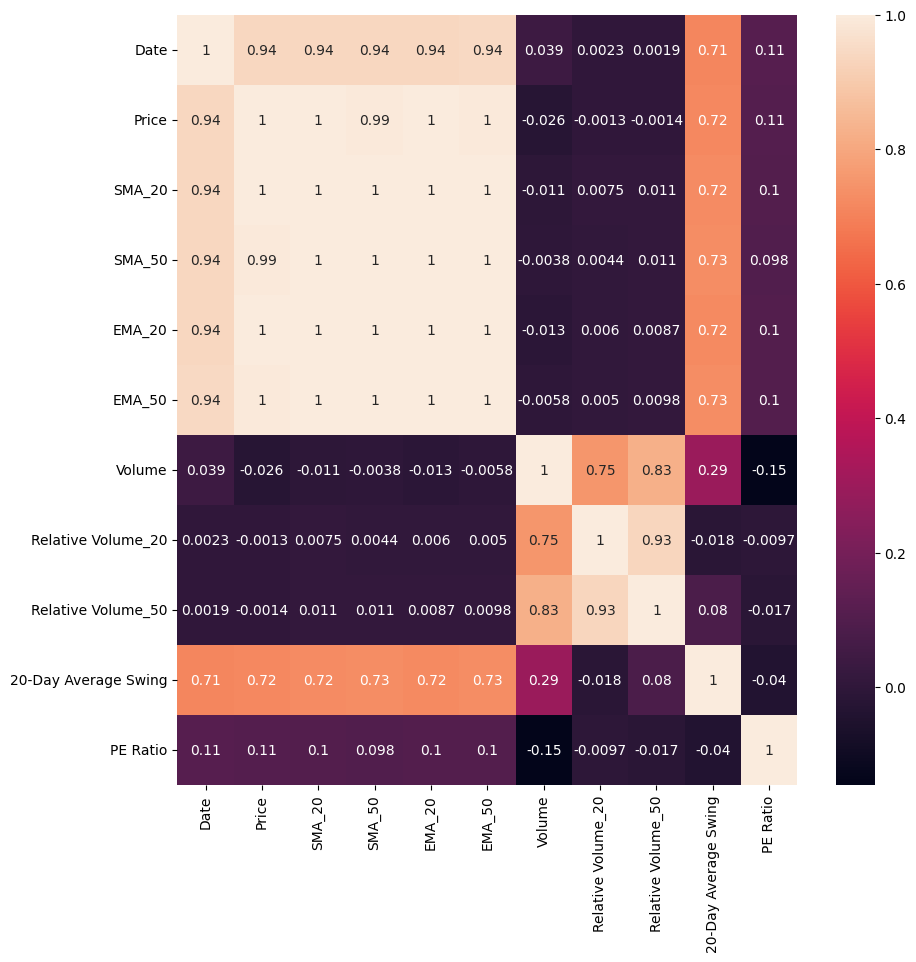

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df.to_csv("BRK-B_final_DF.csv", index=False)
corr_mat=final_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_mat,annot=True)

In [14]:
# Feature Reduction

final_df = pd.read_csv("BRK-B_final_DF.csv")
final_df['Date'] = pd.to_datetime(final_df['Date'])
reduced_df=final_df.drop(columns=["Volume","SMA_20","EMA_20", "EMA_50","Relative Volume_20"])
reduced_df.head()

,Date,Price,SMA_50,Relative Volume_50,20-Day Average Swing,PE Ratio
0,2016-01-19,127.760002,132.876801,1.418847,2.232501,16.438089
1,2016-01-20,124.830002,132.642001,1.900829,2.196501,16.061104
2,2016-01-21,125.620003,132.427801,0.901300,2.207500,16.162749
3,2016-01-22,127.040001,132.288601,0.896484,2.208500,16.345451
4,2016-01-25,124.129997,132.076601,1.236548,2.301000,15.971039


<Axes: >

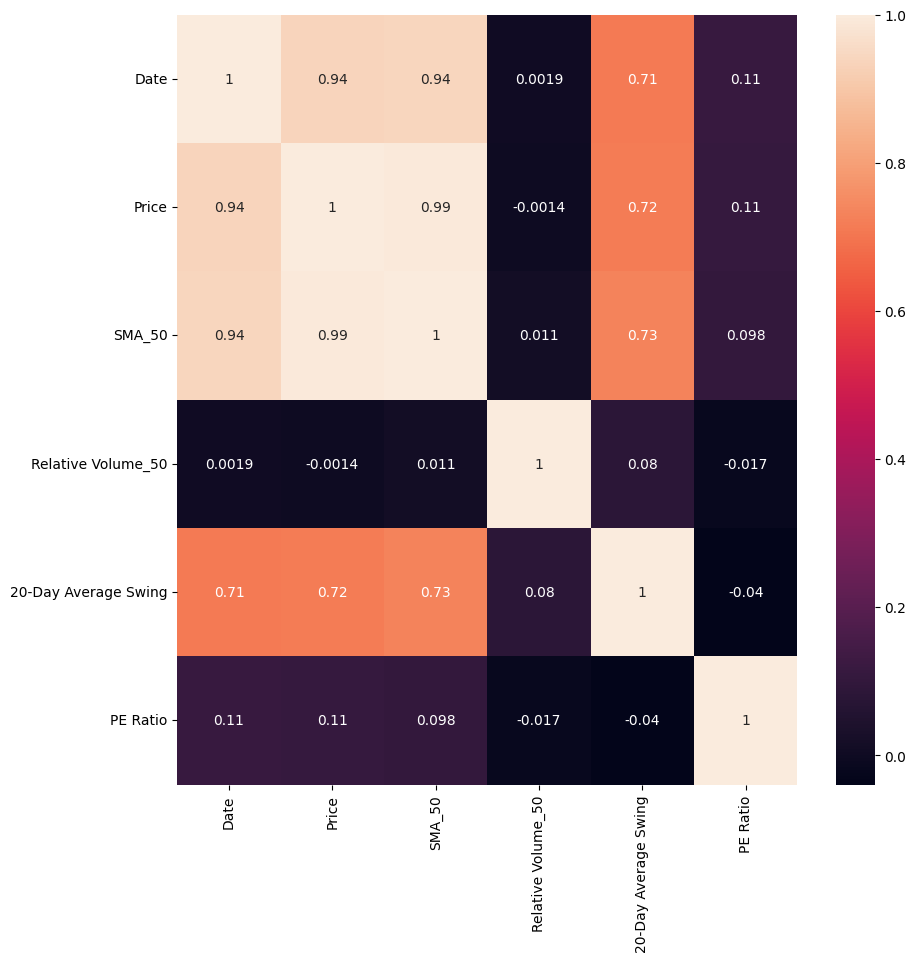

In [15]:
reduced_corr=reduced_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(reduced_corr,annot=True)

## LSTM

In [16]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Setting index as Date
if 'Date' in reduced_df.columns:
    reduced_df = reduced_df.set_index('Date')

# 2. Target and feature columns
target_col = 'Price'
feature_cols = [col for col in reduced_df.columns if col != target_col]
n_features = len(feature_cols)

# 3. Creating scalers
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# 4. Convert Pandas DataFrame columns into NumPy arrays
df_target = reduced_df[[target_col]].values
df_features = reduced_df[feature_cols].values

# 5. Scale data - all features and target normalized to [0,1]
scaled_target = target_scaler.fit_transform(df_target)
scaled_features = feature_scaler.fit_transform(df_features)
# x_scaled​ = (​x−x_min​​)/(x_max​−x_min)

# 6. Combine the scaled data
scaled_data = np.concatenate([scaled_target, scaled_features], axis=1)

# 7. Train-test split (80% training and 20% testing)
train_split_ratio = 0.8
train_size = int(len(scaled_data) * train_split_ratio)
test_size = len(scaled_data) - train_size

train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:, :]

print(f"Number of features (not including target): {n_features}")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Number of features (not including target): 4
Training samples: 1956
Test samples: 490


In [17]:
def create_sequences_simple(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

seq_length = 90
n_all_features = scaled_data.shape[1]

X_train, y_train = create_sequences_simple(train_data, seq_length)

test_data_with_overlap = scaled_data[train_size - seq_length:, :]
X_test, y_test_scaled = create_sequences_simple(test_data_with_overlap, seq_length)

y_test_actual = reduced_df[target_col].iloc[train_size:].values

# print(X_train)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1866, 90, 5)
y_train shape: (1866,)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

n_timesteps = 50
n_features = 4

model = Sequential()

model.add(LSTM(units=200, return_sequences=True, input_shape=(seq_length, n_all_features)))
model.add(Dropout(0.2))

model.add(LSTM(units=200, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=200, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=100, activation='relu'))

# model.add(Dense(units=n_features))
model.add(Dense(units=1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 200)        │       164,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 90, 200)        │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,601 (3.15 MB)

 Trainable params: 826,601 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.save_weights("reduced_weights.weights.h5")

In [20]:
model.load_weights("reduced_weights.weights.h5")

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step
Test Root Mean Squared Error (RMSE): 328.37846380320036


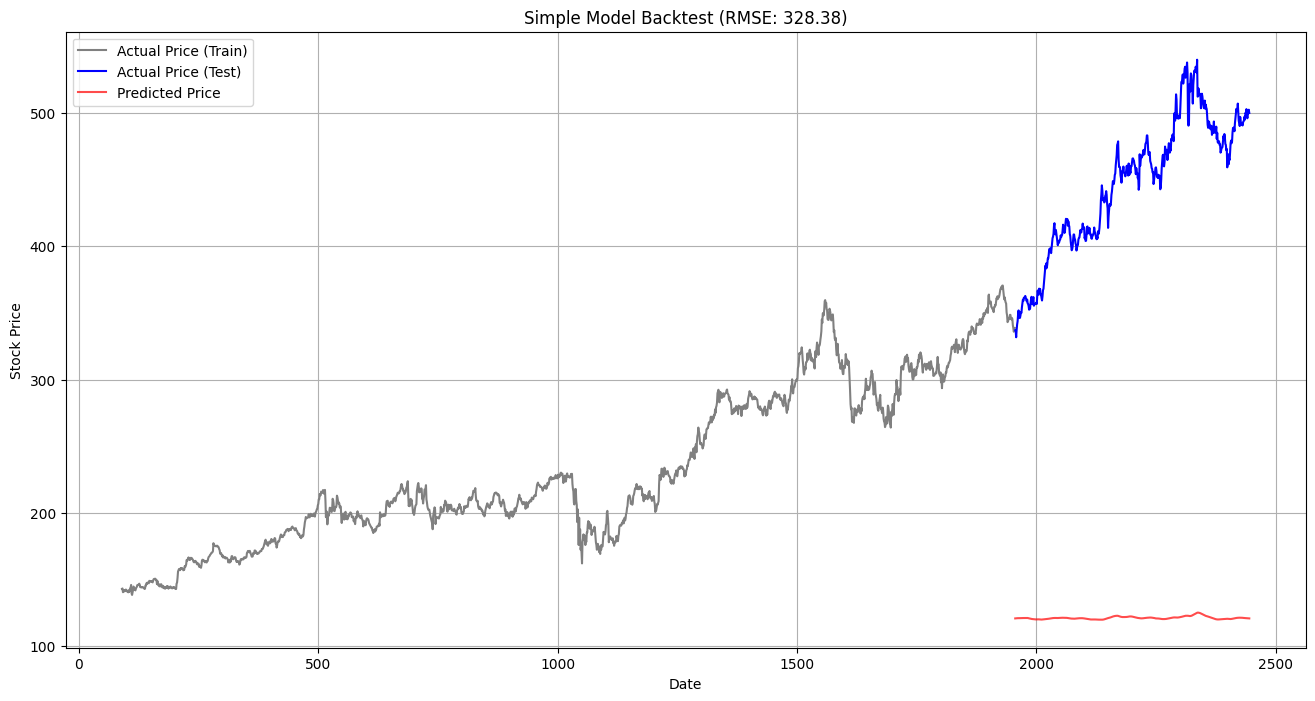

In [21]:
from sklearn.metrics import mean_squared_error

predictions_scaled = model.predict(X_test)

predictions = target_scaler.inverse_transform(predictions_scaled)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Test Root Mean Squared Error (RMSE): {rmse}')

train_dates = final_df.index[seq_length:train_size]
test_dates = final_df.index[train_size:]
actual_train_data = final_df[target_col].iloc[seq_length:train_size]

plt.figure(figsize=(16, 8))
plt.plot(train_dates, actual_train_data, color='gray', label='Actual Price (Train)')
plt.plot(test_dates, y_test_actual, color='blue', label='Actual Price (Test)')
plt.plot(test_dates, predictions, color='red', label='Predicted Price', alpha=0.7)
plt.title(f'Simple Model Backtest (RMSE: {rmse:.2f})')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

Starting simple forecast loop for 60 days...
Forecast loop complete.


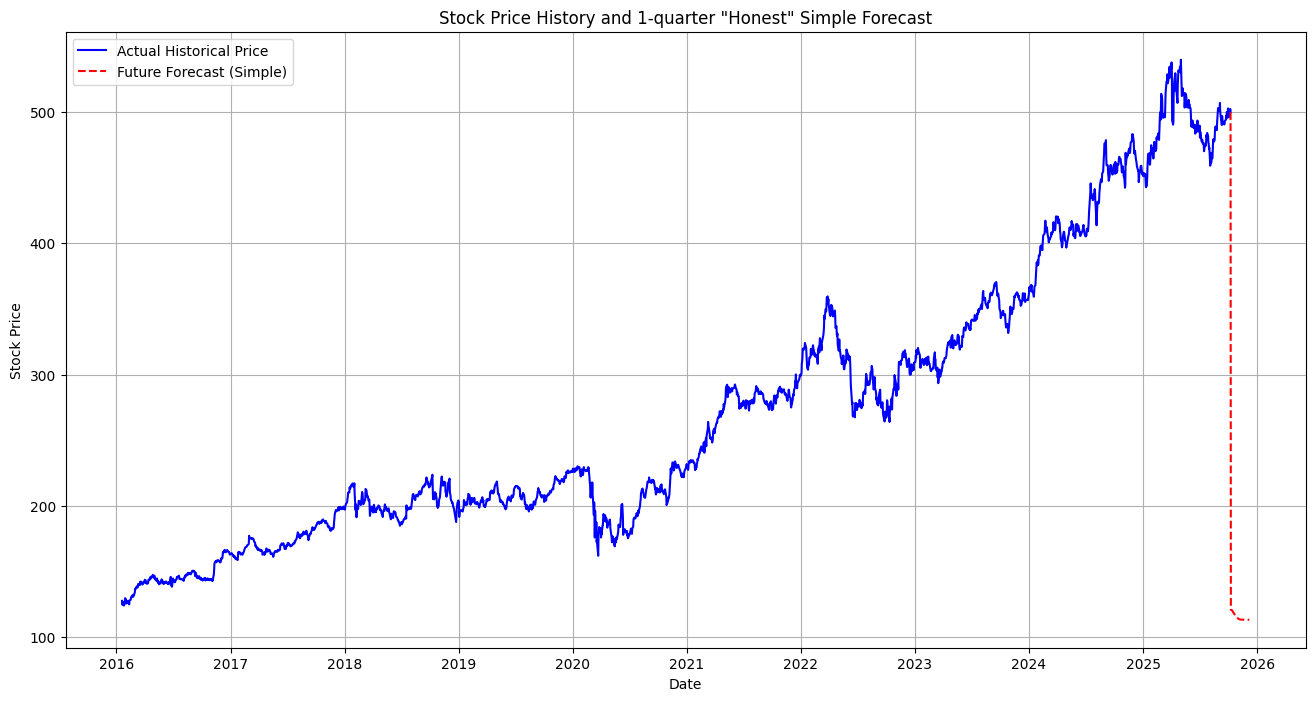

In [22]:
n_future_days = 60
seq_length = 90

last_known_sequence = scaled_data[-seq_length:]

future_predictions_scaled = []

current_sequence = last_known_sequence

print(f"Starting simple forecast loop for {n_future_days} days...")
for i in range(n_future_days):
    current_sequence_reshaped = np.reshape(current_sequence, (1, seq_length, n_all_features))

    next_prediction_scaled = model.predict(current_sequence_reshaped, verbose=0)

    future_predictions_scaled.append(next_prediction_scaled[0][0])

    new_row = current_sequence[-1, :].copy()

    new_row[0] = next_prediction_scaled[0][0]

    current_sequence = np.append(current_sequence, [new_row], axis=0)
    current_sequence = current_sequence[1:, :]

print("Forecast loop complete.")

predictions = target_scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

last_date = reduced_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_future_days)

last_actual_price = reduced_df[target_col].iloc[-1]
last_actual_date = reduced_df.index[-1]

plot_predictions = np.insert(predictions, 0, last_actual_price)
plot_dates = future_dates.insert(0, last_actual_date)

plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index, reduced_df[target_col], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='--', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

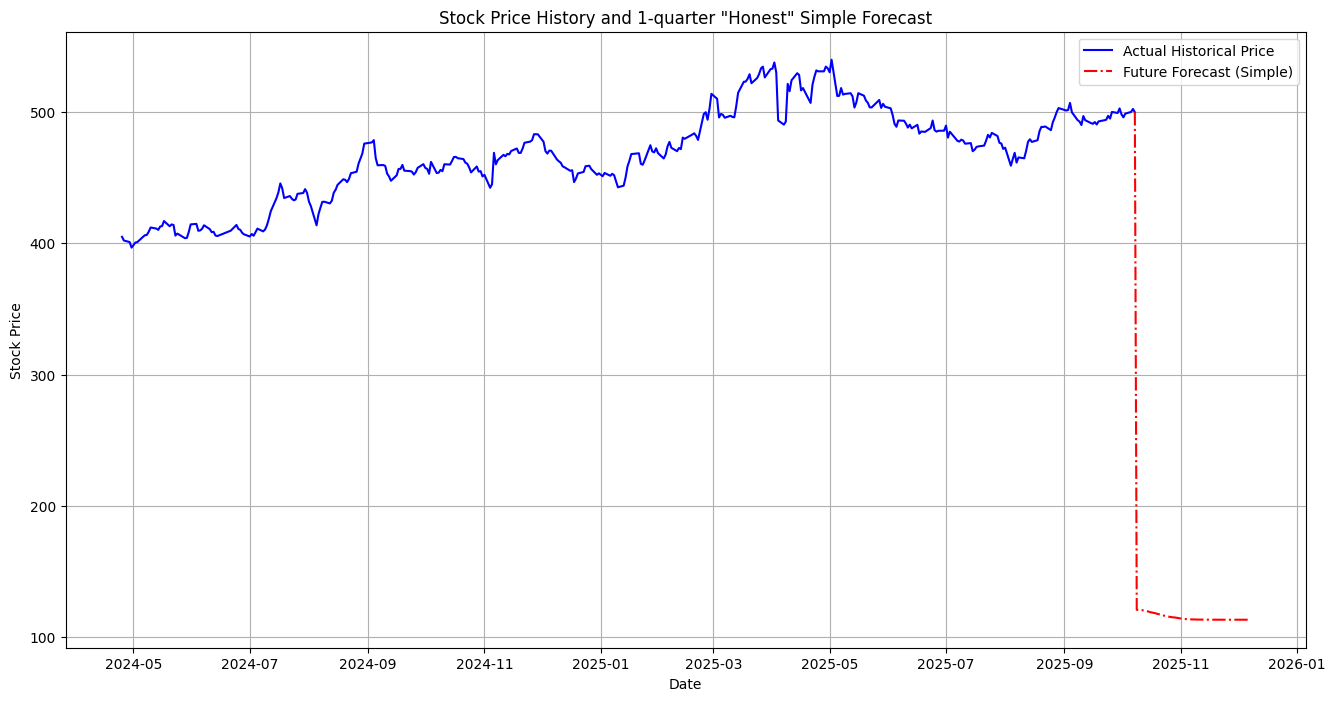

In [23]:
plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index[-365:], reduced_df[target_col][-365:], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='-.', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()